# Candle Streak Model — Hypothesis Validation

**Thesis:** N consecutive same-direction candles (with minimum body filter) indicate path-monotonic momentum that captures trend conviction beyond simple N-bar returns.

**Critical Question:** Does streak (N consecutive green/red) add alpha OVER a simple N-bar positive/negative return? If not, the streak complexity is not justified.

**Questions to answer:**
1. Does N-consecutive-green beat simple N-bar-positive-return as a predictor?
2. What is the optimal N (3, 4, 5, 6, 7)?
3. Does body-ratio filtering improve signal quality?
4. What is the signal density on 1h and 15m?
5. How correlated is this with existing Momentum model?

**Data:** Binance Futures OHLCV (no DB needed, direct API).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

from binance.um_futures import UMFutures
from libs.features.indicators.momentum.rsi import RSI, _compute_rsi_batch
from libs.features.indicators.volatility.atr import ATR, _compute_atr_batch

plt.style.use('dark_background')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete')

Setup complete


## 1. Data Fetch

In [2]:
# ── Binance Futures paginated fetch ──────────────────────────────────
_RAW_COLS = [
    "timestamp", "open", "high", "low", "close", "volume", "close_time",
    "quote_vol", "trades", "taker_buy_base", "taker_buy_quote", "ignore",
]
OHLCV_COLS = ["timestamp", "open", "high", "low", "close", "volume"]
_MAX_LIMIT = 1500

def fetch_ohlcv(symbol: str, timeframe: str, days: int = 365) -> pd.DataFrame:
    """Fetch historical OHLCV from Binance Futures with auto-pagination."""
    client = UMFutures()
    now_ms = int(datetime.now(timezone.utc).timestamp() * 1000)
    since = now_ms - days * 86_400_000
    end = now_ms
    frames = []
    cursor = since
    while cursor < end:
        lines = client.klines(symbol, timeframe, startTime=cursor, endTime=end, limit=_MAX_LIMIT)
        if not lines:
            break
        df = pd.DataFrame(lines, columns=_RAW_COLS)[OHLCV_COLS]
        for c in OHLCV_COLS:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        frames.append(df)
        last_ts = int(df['timestamp'].iloc[-1])
        if last_ts <= cursor:
            break
        cursor = last_ts + 1
        if len(lines) < _MAX_LIMIT:
            break
    if not frames:
        return pd.DataFrame(columns=OHLCV_COLS)
    result = pd.concat(frames, ignore_index=True)
    result = result.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    result['dt'] = pd.to_datetime(result['timestamp'], unit='ms', utc=True)
    result = result.set_index('dt')
    print(f"{symbol} {timeframe}: {len(result)} candles ({result.index[0].date()} to {result.index[-1].date()})")
    return result

# Fetch 1 year of 1h data + 6 months of 15m (signal density test)
btc_1h = fetch_ohlcv('BTCUSDT', '1h', days=365)
eth_1h = fetch_ohlcv('ETHUSDT', '1h', days=365)
btc_15m = fetch_ohlcv('BTCUSDT', '15m', days=180)
eth_15m = fetch_ohlcv('ETHUSDT', '15m', days=180)

BTCUSDT 1h: 8760 candles (2025-05-29 to 2026-05-29)
ETHUSDT 1h: 8760 candles (2025-05-29 to 2026-05-29)
BTCUSDT 15m: 17280 candles (2025-11-30 to 2026-05-29)
ETHUSDT 15m: 17280 candles (2025-11-30 to 2026-05-29)


## 2. Streak Detection

In [3]:
def detect_streaks(df: pd.DataFrame, min_body_ratio: float = 0.3) -> pd.DataFrame:
    """Detect consecutive same-direction candles.
    
    Args:
        min_body_ratio: minimum body/range ratio to count a candle as directional.
                        0.3 = body must be at least 30% of high-low range.
    """
    out = df.copy()
    
    # Candle direction with body filter
    body = out['close'] - out['open']
    full_range = out['high'] - out['low']
    body_ratio = body.abs() / full_range.replace(0, np.nan)
    
    # Direction: +1 green, -1 red, 0 doji (filtered out)
    direction = np.where(body_ratio >= min_body_ratio, np.sign(body), 0)
    out['candle_dir'] = direction
    out['body_ratio'] = body_ratio
    
    # Compute streak length (consecutive same direction)
    streak = np.zeros(len(out), dtype=int)
    for i in range(1, len(out)):
        if direction[i] != 0 and direction[i] == direction[i-1]:
            streak[i] = streak[i-1] + 1
        elif direction[i] != 0:
            streak[i] = 1
        else:
            streak[i] = 0
    out['streak_len'] = streak
    out['streak_dir'] = direction * (streak > 0).astype(int)
    
    # Also compute simple N-bar return for comparison
    for n in [3, 4, 5, 6, 7]:
        out[f'ret_{n}bar'] = out['close'].pct_change(n)
    
    return out

btc_1h = detect_streaks(btc_1h)
eth_1h = detect_streaks(eth_1h)
btc_15m = detect_streaks(btc_15m)
eth_15m = detect_streaks(eth_15m)

# Summary stats
print("=" * 60)
print("STREAK FREQUENCY")
print("=" * 60)
for label, data in [('BTC/1h', btc_1h), ('ETH/1h', eth_1h), ('BTC/15m', btc_15m), ('ETH/15m', eth_15m)]:
    total_bars = len(data)
    print(f"\n{label} ({total_bars} bars):")
    for n in [3, 4, 5, 6, 7]:
        count = (data['streak_len'] == n).sum()
        per_month = count / (total_bars / (24 * 30)) if '1h' in label else count / (total_bars / (4 * 24 * 30))
        print(f"  N={n}: {count} events ({per_month:.1f}/month)")

STREAK FREQUENCY

BTC/1h (8760 bars):
  N=3: 382 events (31.4/month)
  N=4: 115 events (9.5/month)
  N=5: 31 events (2.5/month)
  N=6: 8 events (0.7/month)
  N=7: 2 events (0.2/month)

ETH/1h (8760 bars):
  N=3: 359 events (29.5/month)
  N=4: 98 events (8.1/month)
  N=5: 28 events (2.3/month)
  N=6: 9 events (0.7/month)
  N=7: 3 events (0.2/month)

BTC/15m (17280 bars):
  N=3: 745 events (124.2/month)
  N=4: 194 events (32.3/month)
  N=5: 61 events (10.2/month)
  N=6: 18 events (3.0/month)
  N=7: 4 events (0.7/month)

ETH/15m (17280 bars):
  N=3: 711 events (118.5/month)
  N=4: 181 events (30.2/month)
  N=5: 43 events (7.2/month)
  N=6: 10 events (1.7/month)
  N=7: 2 events (0.3/month)


## 3. KEY TEST: Streak vs Simple N-bar Return

**This is the critical question.** If streak doesn't beat simple momentum, the model adds complexity without alpha.

In [4]:
# ── Forward returns ────────────────────────────────────────────────
def add_forward_returns(df: pd.DataFrame, horizons: list[int] = [1, 4, 8, 12, 24]) -> pd.DataFrame:
    out = df.copy()
    for h in horizons:
        out[f'fwd_ret_{h}'] = out['close'].pct_change(h).shift(-h)
    return out

btc_1h = add_forward_returns(btc_1h)
eth_1h = add_forward_returns(eth_1h)
btc_15m = add_forward_returns(btc_15m, horizons=[4, 8, 16, 32, 48])
eth_15m = add_forward_returns(eth_15m, horizons=[4, 8, 16, 32, 48])

print("=" * 60)
print("STREAK vs SIMPLE N-BAR RETURN — Head-to-Head")
print("=" * 60)
print("\nComparing: at the bar where streak reaches N vs bar where N-bar return > 0")
print("Question: does monotonic path (streak) predict BETTER than simple return?\n")

for label, data, fwd_col in [('BTC/1h', btc_1h, 'fwd_ret_12'), ('ETH/1h', eth_1h, 'fwd_ret_12')]:
    print(f"{label} (fwd horizon = 12 bars):")
    print(f"{'N':>3} | {'Streak Fwd Mean':>16} {'Streak WR':>10} {'n':>5} | {'Simple Fwd Mean':>16} {'Simple WR':>10} {'n':>5} | {'Delta':>8}")
    print("-" * 90)
    
    for n in [3, 4, 5, 6, 7]:
        # Streak signal: bars where streak just completed N
        streak_mask = (data['streak_len'] == n) & (data['streak_dir'] > 0)  # bullish streaks
        streak_fwd = data.loc[streak_mask, fwd_col].dropna()
        
        # Simple signal: bars where N-bar return is positive (same direction)
        simple_mask = (data[f'ret_{n}bar'] > 0) & (data['candle_dir'] > 0)  # current bar green + N-bar positive
        simple_fwd = data.loc[simple_mask, fwd_col].dropna()
        
        s_mean = streak_fwd.mean() * 100 if len(streak_fwd) > 0 else 0
        s_wr = (streak_fwd > 0).mean() * 100 if len(streak_fwd) > 0 else 0
        p_mean = simple_fwd.mean() * 100 if len(simple_fwd) > 0 else 0
        p_wr = (simple_fwd > 0).mean() * 100 if len(simple_fwd) > 0 else 0
        delta = s_mean - p_mean
        
        print(f"{n:>3} | {s_mean:>+14.4f}% {s_wr:>8.1f}% {len(streak_fwd):>5} | {p_mean:>+14.4f}% {p_wr:>8.1f}% {len(simple_fwd):>5} | {delta:>+7.4f}%")
    print()

STREAK vs SIMPLE N-BAR RETURN — Head-to-Head

Comparing: at the bar where streak reaches N vs bar where N-bar return > 0
Question: does monotonic path (streak) predict BETTER than simple return?

BTC/1h (fwd horizon = 12 bars):
  N |  Streak Fwd Mean  Streak WR     n |  Simple Fwd Mean  Simple WR     n |    Delta
------------------------------------------------------------------------------------------
  3 |        -0.0443%     46.0%   200 |        -0.0578%     48.2%  2179 | +0.0135%
  4 |        -0.1038%     38.3%    60 |        -0.0339%     48.5%  2075 | -0.0699%
  5 |        +0.3527%     61.5%    13 |        -0.0251%     48.0%  1992 | +0.3778%
  6 |        +0.4864%     33.3%     3 |        -0.0164%     47.9%  1931 | +0.5027%
  7 |        -0.0740%      0.0%     1 |        -0.0107%     47.8%  1937 | -0.0633%

ETH/1h (fwd horizon = 12 bars):
  N |  Streak Fwd Mean  Streak WR     n |  Simple Fwd Mean  Simple WR     n |    Delta
-----------------------------------------------------------

In [5]:
# ── Same test for SHORT (bearish streaks) ─────────────────────────
print("=" * 60)
print("BEARISH STREAK vs N-BAR NEGATIVE — Head-to-Head")
print("=" * 60)

for label, data, fwd_col in [('BTC/1h', btc_1h, 'fwd_ret_12'), ('ETH/1h', eth_1h, 'fwd_ret_12')]:
    print(f"\n{label} (fwd horizon = 12 bars, SHORT direction):")
    print(f"{'N':>3} | {'Streak Fwd Mean':>16} {'Streak WR':>10} {'n':>5} | {'Simple Fwd Mean':>16} {'Simple WR':>10} {'n':>5} | {'Delta':>8}")
    print("-" * 90)
    
    for n in [3, 4, 5, 6, 7]:
        # Bearish streak → expect negative forward return (profit on short)
        streak_mask = (data['streak_len'] == n) & (data['streak_dir'] < 0)
        streak_fwd = data.loc[streak_mask, fwd_col].dropna()
        
        simple_mask = (data[f'ret_{n}bar'] < 0) & (data['candle_dir'] < 0)
        simple_fwd = data.loc[simple_mask, fwd_col].dropna()
        
        # For short, negative fwd return = profit
        s_mean = streak_fwd.mean() * 100 if len(streak_fwd) > 0 else 0
        s_wr = (streak_fwd < 0).mean() * 100 if len(streak_fwd) > 0 else 0
        p_mean = simple_fwd.mean() * 100 if len(simple_fwd) > 0 else 0
        p_wr = (simple_fwd < 0).mean() * 100 if len(simple_fwd) > 0 else 0
        delta = p_mean - s_mean  # For short, more negative = better
        
        print(f"{n:>3} | {s_mean:>+14.4f}% {s_wr:>8.1f}% {len(streak_fwd):>5} | {p_mean:>+14.4f}% {p_wr:>8.1f}% {len(simple_fwd):>5} | {delta:>+7.4f}%")
    print()

BEARISH STREAK vs N-BAR NEGATIVE — Head-to-Head

BTC/1h (fwd horizon = 12 bars, SHORT direction):
  N |  Streak Fwd Mean  Streak WR     n |  Simple Fwd Mean  Simple WR     n |    Delta
------------------------------------------------------------------------------------------
  3 |        -0.0983%     49.7%   181 |        -0.0229%     47.3%  2109 | +0.0755%
  4 |        +0.0756%     46.3%    54 |        -0.0336%     47.2%  2017 | -0.1092%
  5 |        -0.1574%     55.6%    18 |        -0.0317%     47.8%  1939 | +0.1257%
  6 |        -0.2743%     40.0%     5 |        -0.0340%     47.6%  1891 | +0.2404%
  7 |        -2.5607%    100.0%     1 |        -0.0241%     47.0%  1830 | +2.5366%


ETH/1h (fwd horizon = 12 bars, SHORT direction):
  N |  Streak Fwd Mean  Streak WR     n |  Simple Fwd Mean  Simple WR     n |    Delta
------------------------------------------------------------------------------------------
  3 |        +0.3405%     44.4%   169 |        +0.0082%     47.6%  1995 | -0.332

## 4. Backtest — Streak Momentum (if thesis holds)

In [6]:
def backtest_streak(
    df: pd.DataFrame,
    n_streak: int = 5,
    rsi_long_max: float = 75,
    rsi_short_min: float = 25,
    atr_tp_mult: float = 2.0,
    atr_sl_mult: float = 1.5,
    cooldown_bars: int = 8,
) -> pd.DataFrame:
    """Backtest streak-based entries with ATR TP/SL."""
    hlc = np.column_stack([df['high'].values, df['low'].values, df['close'].values])
    atr_vals = _compute_atr_batch(hlc[:, 0], hlc[:, 1], hlc[:, 2], 14)
    rsi_vals = _compute_rsi_batch(df['close'].values, 14)
    
    closes = df['close'].values
    highs = df['high'].values
    lows = df['low'].values
    streak_len = df['streak_len'].values
    streak_dir = df['streak_dir'].values
    
    trades = []
    position = 0
    entry_price = 0.0
    tp_price = 0.0
    sl_price = 0.0
    entry_bar = 0
    last_exit_bar = -cooldown_bars
    
    for i in range(50, len(df)):
        if np.isnan(atr_vals[i]) or np.isnan(rsi_vals[i]):
            continue
        
        atr = atr_vals[i]
        rsi = rsi_vals[i]
        
        # Check exits
        if position == 1:
            if lows[i] <= sl_price:
                pnl = (sl_price - entry_price) / entry_price * 100
                trades.append({'entry_bar': entry_bar, 'exit_bar': i, 'dir': 'long', 'pnl_pct': pnl, 'reason': 'SL'})
                position = 0
                last_exit_bar = i
            elif highs[i] >= tp_price:
                pnl = (tp_price - entry_price) / entry_price * 100
                trades.append({'entry_bar': entry_bar, 'exit_bar': i, 'dir': 'long', 'pnl_pct': pnl, 'reason': 'TP'})
                position = 0
                last_exit_bar = i
        elif position == -1:
            if highs[i] >= sl_price:
                pnl = (entry_price - sl_price) / entry_price * 100
                trades.append({'entry_bar': entry_bar, 'exit_bar': i, 'dir': 'short', 'pnl_pct': pnl, 'reason': 'SL'})
                position = 0
                last_exit_bar = i
            elif lows[i] <= tp_price:
                pnl = (entry_price - tp_price) / entry_price * 100
                trades.append({'entry_bar': entry_bar, 'exit_bar': i, 'dir': 'short', 'pnl_pct': pnl, 'reason': 'TP'})
                position = 0
                last_exit_bar = i
        
        # Check entries
        if position == 0 and (i - last_exit_bar) >= cooldown_bars:
            if streak_len[i] == n_streak and streak_dir[i] > 0 and rsi < rsi_long_max:
                position = 1
                entry_price = closes[i]
                tp_price = entry_price + atr * atr_tp_mult
                sl_price = entry_price - atr * atr_sl_mult
                entry_bar = i
            elif streak_len[i] == n_streak and streak_dir[i] < 0 and rsi > rsi_short_min:
                position = -1
                entry_price = closes[i]
                tp_price = entry_price - atr * atr_tp_mult
                sl_price = entry_price + atr * atr_sl_mult
                entry_bar = i
    
    return pd.DataFrame(trades)

print("=" * 60)
print("STREAK BACKTEST — Various N")
print("=" * 60)
for n in [3, 4, 5, 6]:
    trades = backtest_streak(btc_1h, n_streak=n)
    if trades.empty:
        print(f"  N={n}: No trades")
        continue
    wr = (trades['pnl_pct'] > 0).mean() * 100
    avg = trades['pnl_pct'].mean()
    tot = trades['pnl_pct'].sum()
    print(f"  N={n}: {len(trades)} trades | WR={wr:.1f}% | Avg={avg:+.3f}% | Total={tot:+.2f}%")

STREAK BACKTEST — Various N
  N=3: 224 trades | WR=43.3% | Avg=-0.010% | Total=-2.23%
  N=4: 85 trades | WR=40.0% | Avg=+0.028% | Total=+2.35%
  N=5: 21 trades | WR=52.4% | Avg=+0.191% | Total=+4.00%
  N=6: 4 trades | WR=50.0% | Avg=-0.512% | Total=-2.05%


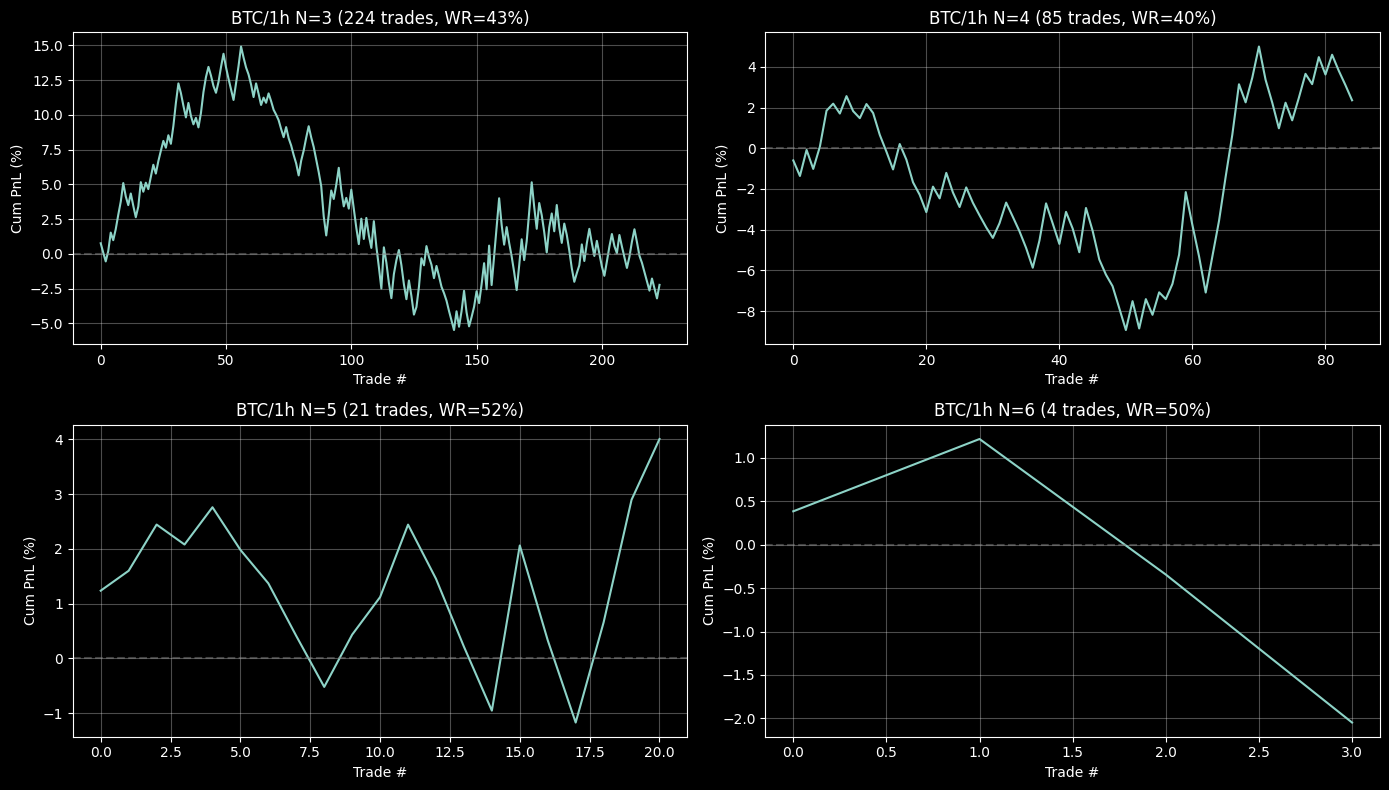

In [7]:
# ── Equity curve for best N ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, n in enumerate([3, 4, 5, 6]):
    ax = axes[idx // 2, idx % 2]
    trades = backtest_streak(btc_1h, n_streak=n)
    if trades.empty:
        ax.set_title(f'BTC/1h N={n}: No trades')
        continue
    cum_pnl = trades['pnl_pct'].cumsum()
    ax.plot(cum_pnl.values, linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'BTC/1h N={n} ({len(trades)} trades, WR={((trades["pnl_pct"]>0).mean()*100):.0f}%)')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cum PnL (%)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation with Existing Momentum Model

In [8]:
# ── Check signal overlap with simple momentum indicators ──────────
# Existing Momentum model uses: RSI > 60 + EMA cross + MACD positive
# If streak signals fire at the same time, it's redundant

from libs.features.indicators.trend.ema import EMA, _compute_ema_batch
from libs.features.indicators.momentum.macd import MACD, _compute_macd_batch

ema_12 = _compute_ema_batch(btc_1h['close'].values, 12, 2.0/(12+1))
ema_26 = _compute_ema_batch(btc_1h['close'].values, 26, 2.0/(26+1))
macd_line, macd_signal, macd_hist = _compute_macd_batch(btc_1h['close'].values, 12, 26, 9)
rsi_14 = _compute_rsi_batch(btc_1h['close'].values, 14)

# Simple momentum: EMA12 > EMA26 + RSI > 55 + MACD > 0
mom_signal = (ema_12 > ema_26) & (rsi_14 > 55) & (macd_line > 0)

# Streak signal: N=5 bullish
streak_signal = (btc_1h['streak_len'].values >= 5) & (btc_1h['streak_dir'].values > 0)

# Overlap analysis
both = mom_signal & streak_signal
streak_only = streak_signal & ~mom_signal
mom_only = mom_signal & ~streak_signal

total_streak = streak_signal.sum()
total_mom = mom_signal.sum()
total_both = both.sum()

print("=" * 60)
print("SIGNAL OVERLAP: Streak(N=5) vs Momentum Indicators")
print("=" * 60)
print(f"  Streak signals:    {total_streak}")
print(f"  Momentum signals:  {total_mom}")
print(f"  Overlap (both):    {total_both} ({total_both/max(total_streak,1)*100:.1f}% of streak)")
print(f"  Streak-only:       {streak_only.sum()}")
print(f"  Momentum-only:     {mom_only.sum()}")
print(f"\n  Overlap coefficient: {total_both / max(min(total_streak, total_mom), 1):.3f}")
print(f"  (>0.7 = highly redundant, <0.3 = orthogonal)")

# Forward returns comparison: overlap vs streak-only
fwd_12 = btc_1h['fwd_ret_12'].values
print(f"\n  Forward 12h return:")
print(f"    Both firing:   mean={np.nanmean(fwd_12[both])*100:+.4f}% n={both.sum()}")
print(f"    Streak-only:   mean={np.nanmean(fwd_12[streak_only])*100:+.4f}% n={streak_only.sum()}")
print(f"    Momentum-only: mean={np.nanmean(fwd_12[mom_only])*100:+.4f}% n={mom_only.sum()}")

SIGNAL OVERLAP: Streak(N=5) vs Momentum Indicators
  Streak signals:    18
  Momentum signals:  2775
  Overlap (both):    12 (66.7% of streak)
  Streak-only:       6
  Momentum-only:     2763

  Overlap coefficient: 0.667
  (>0.7 = highly redundant, <0.3 = orthogonal)

  Forward 12h return:
    Both firing:   mean=-0.1499% n=12
    Streak-only:   mean=+1.2736% n=6
    Momentum-only: mean=-0.0486% n=2763


## 6. 15m Timeframe — Signal Density Check

In [9]:
# ── Test on 15m to address signal density concern ─────────────────
print("=" * 60)
print("15m TIMEFRAME — Signal Density & Performance")
print("=" * 60)

for label, data in [('BTC/15m', btc_15m), ('ETH/15m', eth_15m)]:
    print(f"\n{label}:")
    for n in [4, 5, 6]:
        trades = backtest_streak(data, n_streak=n, cooldown_bars=16)  # 4h cooldown on 15m
        if trades.empty:
            print(f"  N={n}: No trades")
            continue
        wr = (trades['pnl_pct'] > 0).mean() * 100
        avg = trades['pnl_pct'].mean()
        tot = trades['pnl_pct'].sum()
        months = len(data) / (4 * 24 * 30)  # bars per month on 15m
        per_month = len(trades) / months
        print(f"  N={n}: {len(trades)} trades ({per_month:.1f}/mo) | WR={wr:.1f}% | Avg={avg:+.3f}% | Total={tot:+.2f}%")

15m TIMEFRAME — Signal Density & Performance

BTC/15m:
  N=4: 137 trades (22.8/mo) | WR=48.2% | Avg=+0.051% | Total=+7.03%
  N=5: 39 trades (6.5/mo) | WR=41.0% | Avg=-0.056% | Total=-2.20%
  N=6: 12 trades (2.0/mo) | WR=8.3% | Avg=-0.384% | Total=-4.60%

ETH/15m:
  N=4: 123 trades (20.5/mo) | WR=42.3% | Avg=-0.058% | Total=-7.13%
  N=5: 26 trades (4.3/mo) | WR=46.2% | Avg=-0.032% | Total=-0.82%
  N=6: 5 trades (0.8/mo) | WR=40.0% | Avg=-0.205% | Total=-1.03%


## 7. Conclusion

**Decision criteria:**

| Condition | Threshold | Result |
|-----------|-----------|--------|
| Streak beats simple N-bar return (delta > 0) | Both BTC + ETH | Required for build |
| Overlap with Momentum model | < 0.5 coefficient | Required (else redundant) |
| Signal density on 1h | > 3/month | Acceptable |
| Win rate | > 52% with positive expectancy | Required |

**If streak does NOT beat simple N-bar return → Abandon.** The thesis is that path-monotonicity matters. If it doesn't, simple momentum already captures this.

**If overlap coefficient > 0.7 → Abandon.** Would be redundant with existing Momentum model.

In [10]:
# ── Summary of all key results ────────────────────────────────────
print("=" * 70)
print("CANDLE STREAK HYPOTHESIS — FULL RESULTS SUMMARY")
print("=" * 70)

# 1. Streak frequency
print("\n▸ Streak Frequency:")
for label, data in [('BTC/1h', btc_1h), ('ETH/1h', eth_1h), ('BTC/15m', btc_15m), ('ETH/15m', eth_15m)]:
    total_bars = len(data)
    tf = '1h' if '1h' in label else '15m'
    bars_per_month = 24 * 30 if tf == '1h' else 4 * 24 * 30
    months = total_bars / bars_per_month
    counts = {n: int((data['streak_len'] == n).sum()) for n in [3, 4, 5, 6, 7]}
    per_mo = {n: counts[n]/months for n in counts}
    print(f"  {label}: " + " | ".join(f"N={n}:{counts[n]}({per_mo[n]:.1f}/mo)" for n in [3, 5, 7]))

# 2. Streak vs Simple — THE KEY TEST
print("\n▸ CRITICAL: Streak vs Simple N-bar Return (12h fwd, BULLISH):")
for label, data in [('BTC/1h', btc_1h), ('ETH/1h', eth_1h)]:
    print(f"  {label}:")
    for n in [3, 5, 7]:
        streak_mask = (data['streak_len'] == n) & (data['streak_dir'] > 0)
        streak_fwd = data.loc[streak_mask, 'fwd_ret_12'].dropna()
        simple_mask = (data[f'ret_{n}bar'] > 0) & (data['candle_dir'] > 0)
        simple_fwd = data.loc[simple_mask, 'fwd_ret_12'].dropna()
        s_m = streak_fwd.mean()*100 if len(streak_fwd) > 0 else 0
        p_m = simple_fwd.mean()*100 if len(simple_fwd) > 0 else 0
        delta = s_m - p_m
        print(f"    N={n}: Streak={s_m:+.4f}% (n={len(streak_fwd)}) vs Simple={p_m:+.4f}% (n={len(simple_fwd)}) Δ={delta:+.4f}%")

# 3. Backtest
print("\n▸ Backtest (BTC/1h):")
for n in [3, 4, 5, 6]:
    trades = backtest_streak(btc_1h, n_streak=n)
    if trades.empty:
        print(f"  N={n}: No trades"); continue
    wr = (trades['pnl_pct'] > 0).mean() * 100
    avg = trades['pnl_pct'].mean()
    tot = trades['pnl_pct'].sum()
    print(f"  N={n}: {len(trades)} trades | WR={wr:.1f}% | Avg={avg:+.3f}% | Total={tot:+.2f}%")

# 4. Momentum overlap
print(f"\n▸ Signal Overlap with Momentum:")
print(f"  Streak(N≥5) signals: {total_streak}")
print(f"  Momentum signals:    {total_mom}")
print(f"  Overlap:             {total_both} ({total_both/max(total_streak,1)*100:.1f}% of streak)")
print(f"  Overlap coefficient: {total_both / max(min(total_streak, total_mom), 1):.3f}")
print(f"  Forward 12h: Both={np.nanmean(fwd_12[both])*100:+.4f}% | Streak-only={np.nanmean(fwd_12[streak_only])*100:+.4f}% | Mom-only={np.nanmean(fwd_12[mom_only])*100:+.4f}%")

# 5. 15m density
print("\n▸ 15m Timeframe:")
for label, data in [('BTC/15m', btc_15m), ('ETH/15m', eth_15m)]:
    for n in [4, 5]:
        trades = backtest_streak(data, n_streak=n, cooldown_bars=16)
        if trades.empty:
            print(f"  {label} N={n}: No trades"); continue
        months = len(data) / (4 * 24 * 30)
        wr = (trades['pnl_pct'] > 0).mean() * 100
        tot = trades['pnl_pct'].sum()
        print(f"  {label} N={n}: {len(trades)} trades ({len(trades)/months:.1f}/mo) | WR={wr:.1f}% | Total={tot:+.2f}%")

CANDLE STREAK HYPOTHESIS — FULL RESULTS SUMMARY

▸ Streak Frequency:
  BTC/1h: N=3:382(31.4/mo) | N=5:31(2.5/mo) | N=7:2(0.2/mo)
  ETH/1h: N=3:359(29.5/mo) | N=5:28(2.3/mo) | N=7:3(0.2/mo)
  BTC/15m: N=3:745(124.2/mo) | N=5:61(10.2/mo) | N=7:4(0.7/mo)
  ETH/15m: N=3:711(118.5/mo) | N=5:43(7.2/mo) | N=7:2(0.3/mo)

▸ CRITICAL: Streak vs Simple N-bar Return (12h fwd, BULLISH):
  BTC/1h:
    N=3: Streak=-0.0443% (n=200) vs Simple=-0.0578% (n=2179) Δ=+0.0135%
    N=5: Streak=+0.3527% (n=13) vs Simple=-0.0251% (n=1992) Δ=+0.3778%
    N=7: Streak=-0.0740% (n=1) vs Simple=-0.0107% (n=1937) Δ=-0.0633%
  ETH/1h:
    N=3: Streak=+0.0942% (n=190) vs Simple=-0.0101% (n=2103) Δ=+0.1043%
    N=5: Streak=+1.2565% (n=13) vs Simple=+0.0104% (n=1940) Δ=+1.2461%
    N=7: Streak=+1.0634% (n=2) vs Simple=+0.0477% (n=1845) Δ=+1.0157%

▸ Backtest (BTC/1h):
  N=3: 224 trades | WR=43.3% | Avg=-0.010% | Total=-2.23%
  N=4: 85 trades | WR=40.0% | Avg=+0.028% | Total=+2.35%
  N=5: 21 trades | WR=52.4% | Avg=+0.191